In [1]:
import torch
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = True

from src.metrics.alignment.soft_match import SoftMatch
from src.metrics.alignment.partial_wasserstein import UnbalancedSoftMatch
from src.utils.synthesize import generate_neural_representations, concat_noisy_neurons

In [2]:
# instantiate metric objects
# unbalanced soft-matching
unbalanced_sm = UnbalancedSoftMatch(mass_reg=100/190)
# soft-match
sm = SoftMatch()

In [3]:
# init some constant for generating neural representations
k = 50  # num of linearly independent factors
n = 100 # number of neurons
num_stimulus = 1000

In [4]:
# generate a pair of neural representations
z1, z2 = generate_neural_representations(k=k, 
                                         m=num_stimulus, 
                                         n=n,
                                         num_representations=2,
                                         sparsity=0.99)

# concat noisy neurons to {z1, z2}
z1_noisy = concat_noisy_neurons(m=num_stimulus, neuron_signal=z1, num_noisy_neurons=90)
z2_noisy = concat_noisy_neurons(m=num_stimulus, neuron_signal=z2, num_noisy_neurons=90)

In [5]:
# align z1 and z2 using SM + unbalanced SM
mean_sm = np.mean(np.array(sm.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))))
mean_unbalanced_sm = np.mean(np.array(unbalanced_sm.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))))

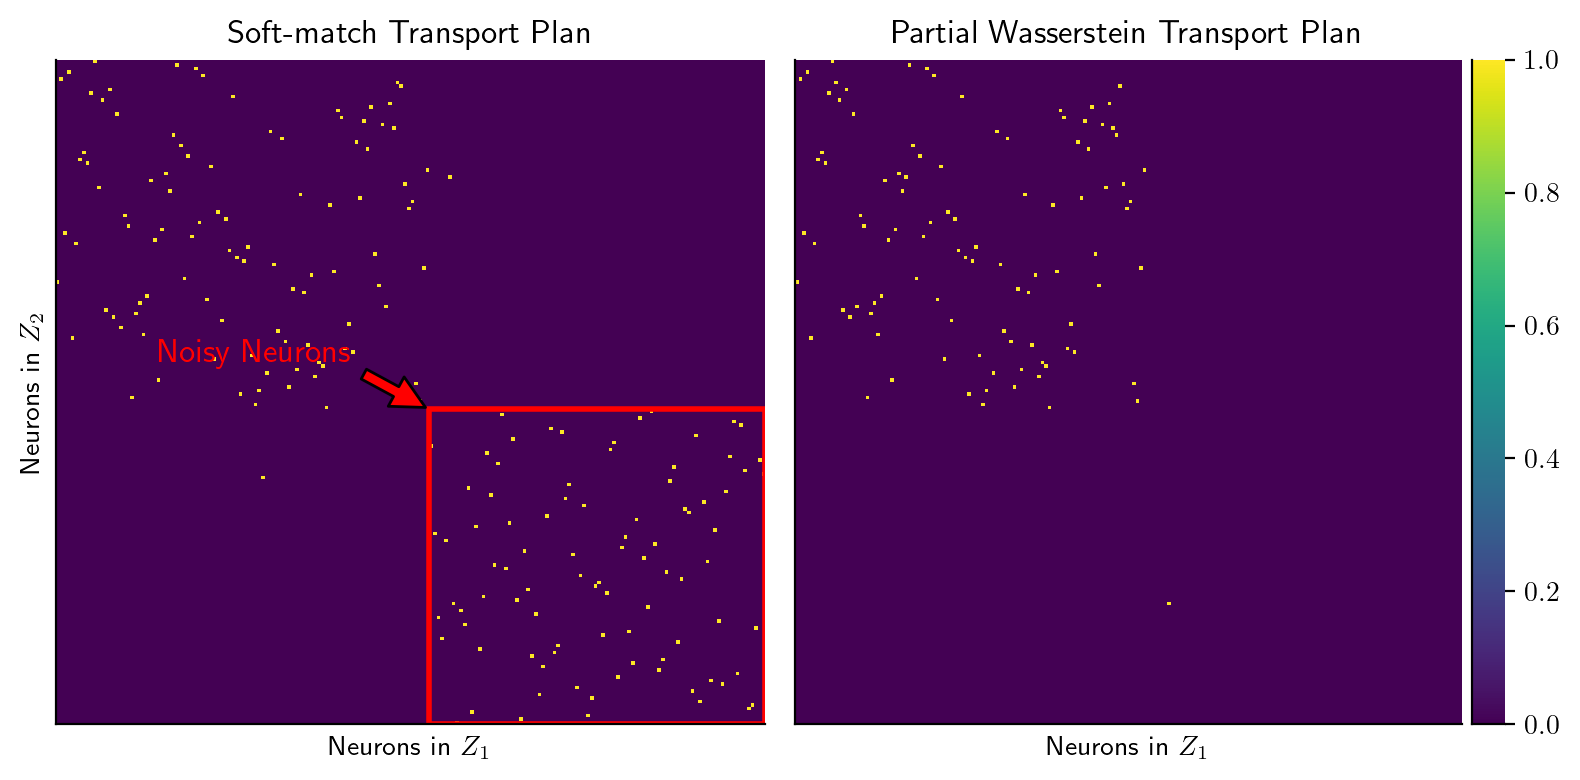

In [6]:
viz1 = sm.transform
if viz1.sum() > 0:
    viz1 = viz1 / viz1.max()

viz2 = unbalanced_sm.transform
if viz2.sum() > 0:
    viz2 = viz2 / viz2.max()

# define the region corresponding to noisy neurons
n_rows, n_cols = viz1.shape
noisy_region_rows = 90
noisy_region_cols = 90

# create figure and subplots with gridspec to control width ratios
fig, axes = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={"width_ratios": [1, 1]})

# soft-match transport plan
ax1 = sns.heatmap(viz1, cmap='viridis', cbar=False, ax=axes[0])
axes[0].set_xlabel(r'Neurons in $Z_1$')
axes[0].set_ylabel(r'Neurons in $Z_2$')
axes[0].set_title(r'Soft-match Transport Plan')
axes[0].set_xticks([])
axes[0].set_yticks([])

# add a red rectangle to highlight noisy neurons
if n_rows >= noisy_region_rows and n_cols >= noisy_region_cols:
    rect = patches.Rectangle((n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                             noisy_region_cols, noisy_region_rows,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)

    # annotate the rectangle
    axes[0].annotate("Noisy Neurons", 
                     xy=(n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                     xycoords='data',
                     xytext=(n_cols - noisy_region_cols - 20, n_rows - noisy_region_rows - 20),
                     textcoords='data',
                     arrowprops=dict(facecolor='red', shrink=0.05),
                     horizontalalignment='right', verticalalignment='top',
                     fontsize=12, color='red')

# unbalanced transport plan
# this is me being super nitpicky about how i want the 
# plot aspect ratios to be exactly balanced
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # create space for the colorbar

ax2 = sns.heatmap(viz2, cmap='viridis', cbar=True, ax=axes[1], cbar_ax=cax)  # assign colorbar to cax
axes[1].set_xlabel(r'Neurons in $Z_1$')
axes[1].set_title(r'Partial Wasserstein Transport Plan')
axes[1].set_xticks([])
axes[1].set_yticks([])

sns.despine(trim=True)
plt.tight_layout()
#plt.savefig('transport-plan-simulation.png', dpi=300)
plt.show()


# brute force deletion of neurons

In [7]:
device = torch.device('cuda:1')

z1_tensor = torch.as_tensor(z1_noisy, device=device)
z2_tensor = torch.as_tensor(z2_noisy, device=device)

# we want to store the indices of neurons deleted
delta_dict = {k: None for k in range(z1_tensor.shape[-1])}

# remove each neuron and see how score the score is impacted
# we want to repeat this over N neurons 
for neuron_idx in tqdm(range(z1_tensor.shape[-1])):
    # delete a specified neuron index from the representation
    if neuron_idx == 0:
        candidate = z1_tensor[:, 1:]
    elif neuron_idx == z1_tensor.shape[1] - 1:
        candidate = z1_tensor[:, :-1]
    else:
        candidate = torch.cat([
                z1_tensor[:, :neuron_idx],
                z1_tensor[:, neuron_idx+1:]
            ], dim=1)

    # refit soft-matching to the augmented representation
    scores = torch.tensor(sm.fit_kfold_score(candidate, z2_tensor))       
    new_score = torch.mean(scores)
    delta = (new_score - mean_sm).item()

    delta_dict[neuron_idx] = delta
        

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 190/190 [00:27<00:00,  6.92it/s]


In [8]:
# sort in order of maximal decreasing score
sorted_delta_dict = {k: v for k, v in sorted(delta_dict.items(),
                                             key=lambda item: item[1],
                                             reverse=True)}

In [10]:
# get the top 90 instances which reduce score
neuron_indices = list(sorted_delta_dict.keys())[:90]

In [13]:
threshold = 1e-4
unmatched_units_row = torch.where(unbalanced_sm.transform.sum(axis=1) < threshold)[0]
unmatched_units_col = torch.where(unbalanced_sm.transform.sum(axis=0) < threshold)[0]

In [17]:
# number of correctly identified units with brute force
sum(np.array(neuron_indices) > 99)

np.int64(82)

In [14]:
# number of correctly identified units with PW
sum(unmatched_units_row > 99), sum(unmatched_units_col > 99)

(tensor(89), tensor(89))

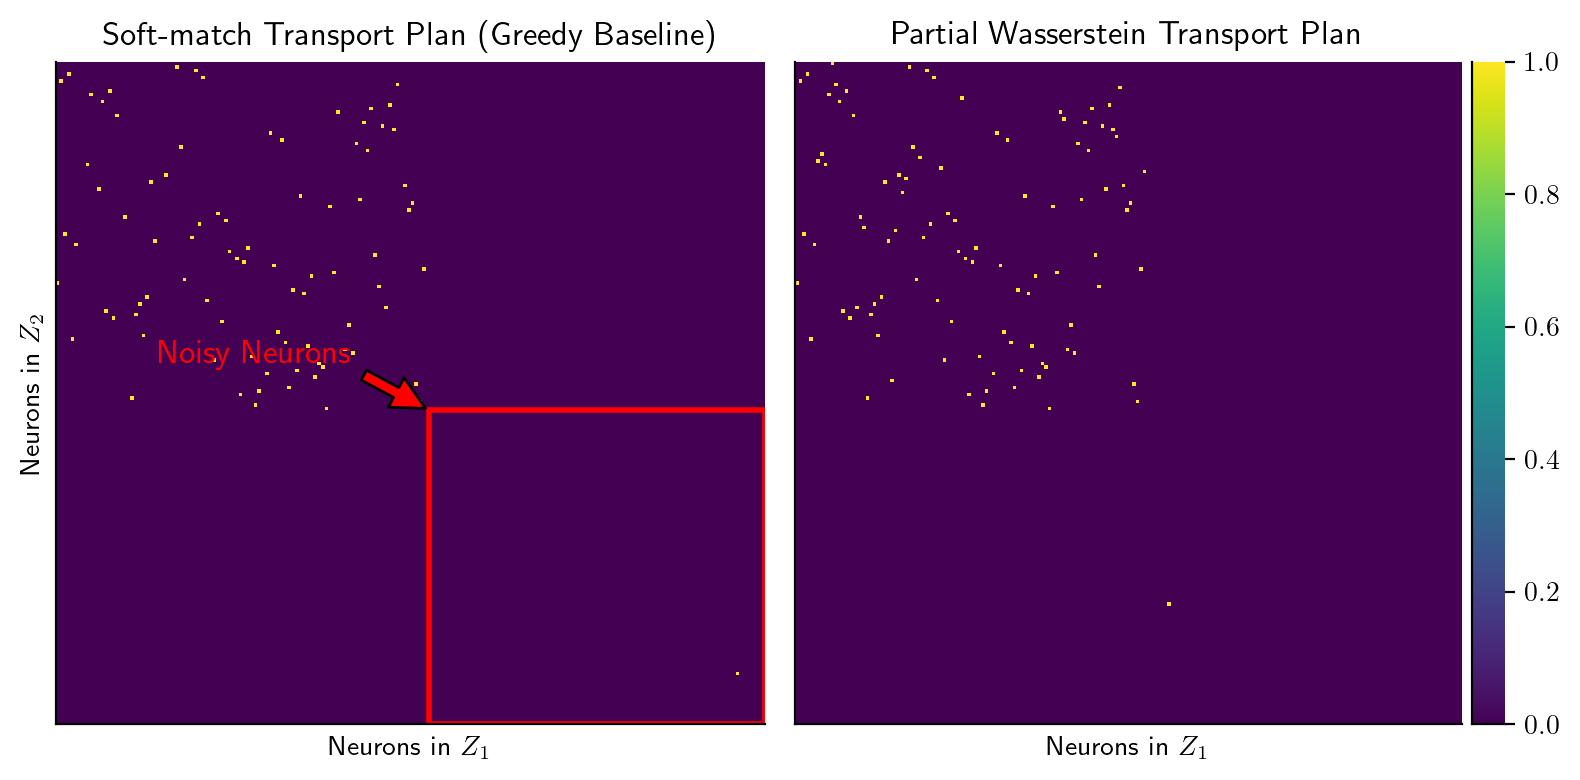

In [34]:
# now, zero out the said indices from the transport plan
# zero out brute force matched indices in soft-matching
# first, refit the transformation to the original dataset
_ = np.mean(np.array(sm.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))))
augmented_sm_transform = sm.transform.cpu().detach().clone()
augmented_sm_transform[neuron_indices,:] = 0
augmented_sm_transform[:,neuron_indices] = 0

viz1 = augmented_sm_transform
if viz1.sum() > 0:
    viz1 = viz1 / viz1.max()

viz2 = unbalanced_sm.transform
if viz2.sum() > 0:
    viz2 = viz2 / viz2.max()


# define the region corresponding to noisy neurons
n_rows, n_cols = viz1.shape
noisy_region_rows = 90
noisy_region_cols = 90

# create figure and subplots with gridspec to control width ratios
fig, axes = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={"width_ratios": [1, 1]})

# soft-match transport plan
ax1 = sns.heatmap(viz1, cmap='viridis', cbar=False, ax=axes[0])
axes[0].set_xlabel(r'Neurons in $Z_1$')
axes[0].set_ylabel(r'Neurons in $Z_2$')
axes[0].set_title(r'Soft-match Transport Plan (Greedy Baseline)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# add a red rectangle to highlight noisy neurons
if n_rows >= noisy_region_rows and n_cols >= noisy_region_cols:
    rect = patches.Rectangle((n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                             noisy_region_cols, noisy_region_rows,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)

    # annotate the rectangle
    axes[0].annotate("Noisy Neurons", 
                     xy=(n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                     xycoords='data',
                     xytext=(n_cols - noisy_region_cols - 20, n_rows - noisy_region_rows - 20),
                     textcoords='data',
                     arrowprops=dict(facecolor='red', shrink=0.05),
                     horizontalalignment='right', verticalalignment='top',
                     fontsize=12, color='red')

# unbalanced transport plan
# this is me being super nitpicky about how i want the 
# plot aspect ratios to be exactly balanced
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # create space for the colorbar

ax2 = sns.heatmap(viz2, cmap='viridis', cbar=True, ax=axes[1], cbar_ax=cax)  # assign colorbar to cax
axes[1].set_xlabel(r'Neurons in $Z_1$')
axes[1].set_title(r'Partial Wasserstein Transport Plan')
axes[1].set_xticks([])
axes[1].set_yticks([])

sns.despine(trim=True)
plt.tight_layout()
plt.show()

# correlation-based unit ordering

In [24]:
def pairwise_correlation(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    compute the pairwise correlation between x and y
    """
    xm = x - torch.mean(x, dim=0, keepdim=True)
    ym = y - torch.mean(y, dim=0, keepdim=True)
    corr_matrix = (xm.T @ ym) / (
        torch.sqrt(torch.sum(xm**2, dim=0, keepdim=True)).T
        * torch.sqrt(torch.sum(ym**2, dim=0, keepdim=True))
    )

    # we care about unit-unit matching
    return torch.diag(corr_matrix)

In [21]:
transformed_rep = torch.tensor(z1_noisy).float() @ sm.transform

In [31]:
# get the unit-unit correlations for all unit pairs
unit_correlations = pairwise_correlation(x=transformed_rep, y=torch.tensor(z2_noisy).float())
# pick the bottom n-correlated units
bottom_indices = unit_correlations.argsort()[:90]

In [36]:
unit_correlations[bottom_indices]

tensor([0.0206, 0.0289, 0.0290, 0.0302, 0.0312, 0.0371, 0.0379, 0.0381, 0.0392,
        0.0409, 0.0422, 0.0449, 0.0451, 0.0459, 0.0497, 0.0504, 0.0504, 0.0512,
        0.0513, 0.0518, 0.0520, 0.0520, 0.0530, 0.0542, 0.0550, 0.0558, 0.0569,
        0.0571, 0.0573, 0.0581, 0.0584, 0.0585, 0.0586, 0.0597, 0.0605, 0.0607,
        0.0608, 0.0625, 0.0630, 0.0632, 0.0639, 0.0642, 0.0644, 0.0645, 0.0651,
        0.0654, 0.0660, 0.0661, 0.0667, 0.0677, 0.0677, 0.0678, 0.0680, 0.0681,
        0.0683, 0.0685, 0.0709, 0.0710, 0.0721, 0.0721, 0.0722, 0.0723, 0.0727,
        0.0728, 0.0741, 0.0745, 0.0748, 0.0756, 0.0775, 0.0778, 0.0789, 0.0795,
        0.0820, 0.0824, 0.0846, 0.0848, 0.0867, 0.0872, 0.0884, 0.0884, 0.0899,
        0.0901, 0.0934, 0.0936, 0.0959, 0.0964, 0.1008, 0.1083, 0.1091, 0.1095])

In [32]:
# number of correctly identified units with a correlation-based score
sum(bottom_indices > 99)

tensor(89)

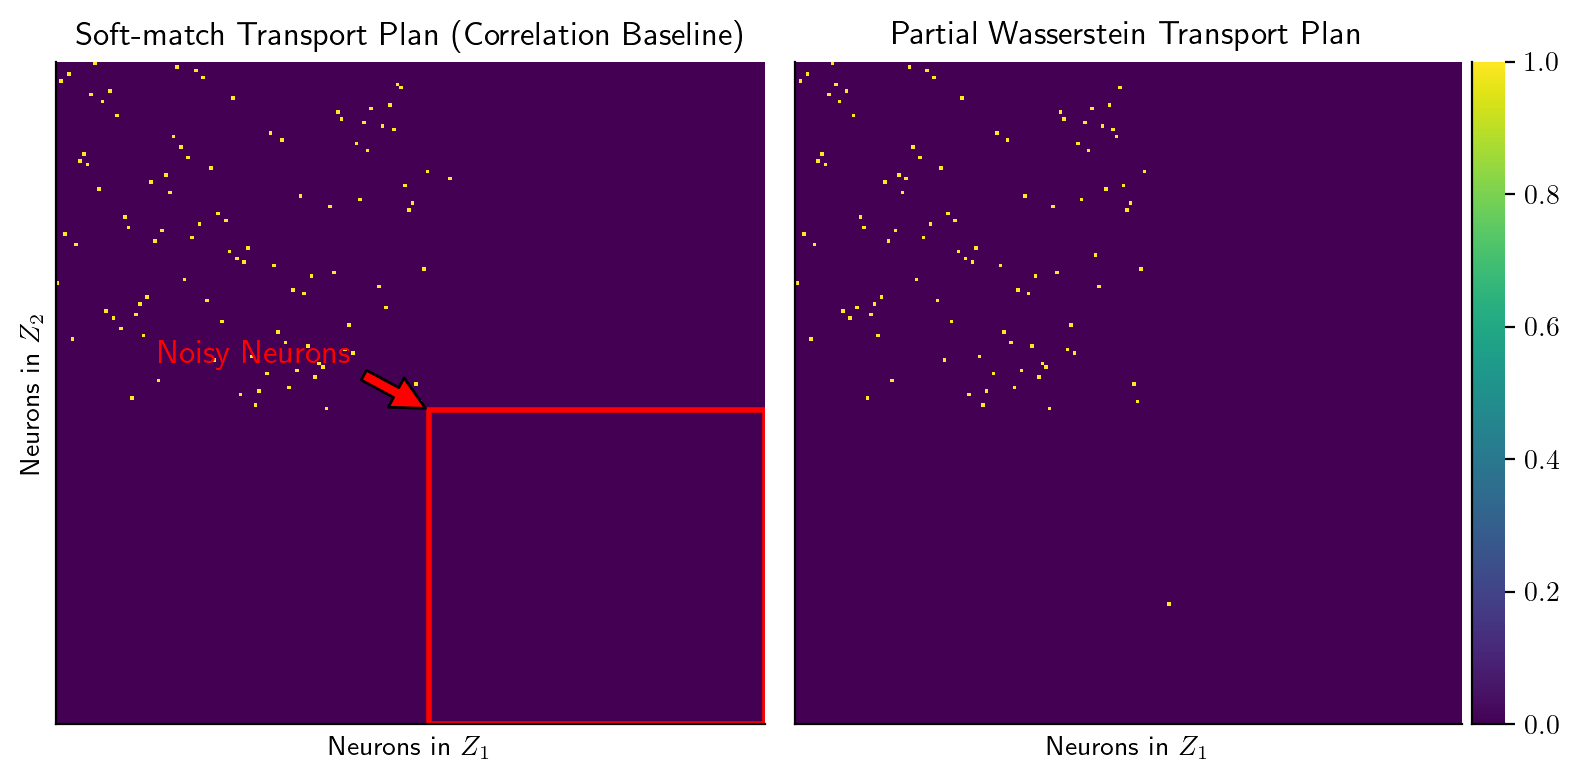

In [35]:
# now, zero out the said indices from the transport plan
# zero out brute force matched indices in soft-matching
# first, refit the transformation to the original dataset
_ = np.mean(np.array(sm.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))))
augmented_sm_transform = sm.transform.cpu().detach().clone()
augmented_sm_transform[bottom_indices,:] = 0
augmented_sm_transform[:,bottom_indices] = 0

viz1 = augmented_sm_transform
if viz1.sum() > 0:
    viz1 = viz1 / viz1.max()

viz2 = unbalanced_sm.transform
if viz2.sum() > 0:
    viz2 = viz2 / viz2.max()


# define the region corresponding to noisy neurons
n_rows, n_cols = viz1.shape
noisy_region_rows = 90
noisy_region_cols = 90

# create figure and subplots with gridspec to control width ratios
fig, axes = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={"width_ratios": [1, 1]})

# soft-match transport plan
ax1 = sns.heatmap(viz1, cmap='viridis', cbar=False, ax=axes[0])
axes[0].set_xlabel(r'Neurons in $Z_1$')
axes[0].set_ylabel(r'Neurons in $Z_2$')
axes[0].set_title(r'Soft-match Transport Plan (Correlation Baseline)')
axes[0].set_xticks([])
axes[0].set_yticks([])

# add a red rectangle to highlight noisy neurons
if n_rows >= noisy_region_rows and n_cols >= noisy_region_cols:
    rect = patches.Rectangle((n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                             noisy_region_cols, noisy_region_rows,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)

    # annotate the rectangle
    axes[0].annotate("Noisy Neurons", 
                     xy=(n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                     xycoords='data',
                     xytext=(n_cols - noisy_region_cols - 20, n_rows - noisy_region_rows - 20),
                     textcoords='data',
                     arrowprops=dict(facecolor='red', shrink=0.05),
                     horizontalalignment='right', verticalalignment='top',
                     fontsize=12, color='red')

# unbalanced transport plan
# this is me being super nitpicky about how i want the 
# plot aspect ratios to be exactly balanced
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # create space for the colorbar

ax2 = sns.heatmap(viz2, cmap='viridis', cbar=True, ax=axes[1], cbar_ax=cax)  # assign colorbar to cax
axes[1].set_xlabel(r'Neurons in $Z_1$')
axes[1].set_title(r'Partial Wasserstein Transport Plan')
axes[1].set_xticks([])
axes[1].set_yticks([])

sns.despine(trim=True)
plt.tight_layout()
plt.show()

# PW baseline